# EXERCISE 08: Optimization problems

## 08.1

<b> Write a Variational Monte Carlo code for a single quantum particle in 1D which exploits the Metropolis algorithm to sample the square modulus of our trial wave function $|\Psi_T^{\sigma,\mu}(x)|^2$ using an uniform transition probability $T(x_{new}|x_{old})$. By using data blocking, the code should be able to compute the expectation value for the Hamiltonian <b>
 $$
\langle {\hat H} \rangle_T = 
\frac{\int dx \Psi^*_T(x) {\hat H} \Psi_T(x)}
{\int dx |\Psi_T(x)|^2} = 
\int dx \frac{|\Psi_T(x)|^2}{\int dx |\Psi_T(x)|^2} \frac{{\hat H} \Psi_T(x)}{\Psi_T(x)}
$$
In which:
$$
\Psi_T^{\sigma,\mu}(x) \propto e^{-\frac{(x-\mu)^2}{2\sigma^2}}+
                               e^{-\frac{(x+\mu)^2}{2\sigma^2}}
$$
$$
V(x) = x^4 - \frac{5}{2}x^2
$$

The expectation value of the hamiltonian can be computed using an importance sampling technique, meaning that we use extract points from the trial wavefunction instead of a uniform distribution to be able to reach an accurate value of the integral faster and in a more precise way. In this first points I used some trial values of mu and sigma that I deduced from the theoretical model that is plotted in the exercise question, which are: $\mu = 0.85$, $\sigma = 0.65$ ( initially I tried sigma = 0.5 and mu = 0.8 and I adjusted it until the histogram approached the theoretical line in a correct way)

#### Metropolis sampling of the wavefunction
In order to do this  I created a modified version of the Metropolis algorithm, that takes 1D steps with an input step length that is chosen so that the acceptance rate approaches 50%, and accceptsmoves with the usual Metropolis acceptance rate(same function I used in exercise 5).
``` c++
void Metropolis_Step(Random& rnd, double &position,double step_length,double &acc_rate, double mu, double sigma){
	
	double old_pos = position;

	double new_pos=old_pos+step_length*rnd.Rannyu(-1,1);
	double p_old = mu,sigma,old_pos;
	double p_new = psi_T(mu,sigma,new_pos);
	double T_bkw=1.;
	double T_fwd =1.;

	double A=Metropolis_Acceptance(p_new,p_old,T_fwd,T_bkw);
	
	double x = rnd.Rannyu();
	if (x<A){
		acc_rate++;
		position = new_pos;
}
else position = old_pos;
}

I first performed an equilibration of the system to let the acceptance rate stabilize to 50%, and in the fllowing plot we can see that 2000 steps with steplength 2.75 are sufficient to reach the desired result. To compare the point distribution with the trial wavefunction I initially executed the simulation with only 1 block of 10000 steps, that resulted in the histogram below:

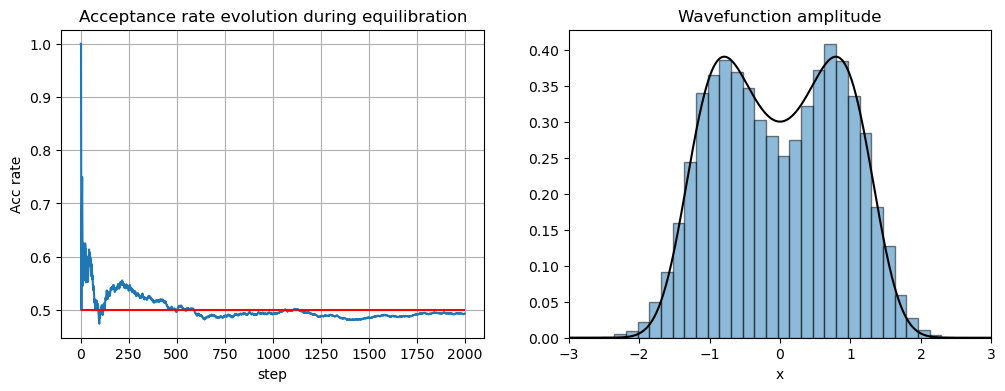

In [49]:
import matplotlib.pyplot as plt
import pandas as pd

fig,ax = plt.subplots(1,2,figsize=(12,4))

#equilibration
df_acc=pd.read_csv("./OUTPUT/acceptance.csv",sep='\t')
ax[0].plot(df_acc['step'],df_acc['acc_rate'])
ax[0].hlines(0.5,0,2000,color='r')
ax[0].set_title("Acceptance rate evolution during equilibration")
ax[0].set_xlabel("step")
ax[0].set_ylabel ("Acc rate")
ax[0].grid()

#MODEL
def Vpot(x):
    return (x**2 - 2.5)*x**2
    #return 0.5*x**2
hbar = 1
m = 1
a = 10
N = 1000 # number of iterations

x = np.linspace(-a/2, a/2, N)
dx = x[1] - x[0] # the step size
V = Vpot(x)

CDiff = np.diag(np.ones(N-1),-1)-2*np.diag(np.ones(N),0)+np.diag(np.ones(N-1),1)
H = (-(hbar**2)*CDiff)/(2*m*dx**2) + np.diag(V)
E,psi = np.linalg.eigh(H)

# Take the transpose & normalize
psi = np.transpose(psi)
psi = psi/np.sqrt(dx)

#DATA
df= pd.read_csv('./OUTPUT/psi_sampling.csv',sep='\t')

#plot
ax[1].plot(x,(psi[0])**2,color='black',label='model')
ax[1].hist(df['x'],bins=30,alpha=0.5,edgecolor='black',density=True,label='sampling')
ax[1].set_title("Wavefunction amplitude")
ax[1].set_xlabel("x")
ax[1].set_xlim((-3,3))

plt.show()

#### Evaluation of $\langle H \rangle$
To evaluate the integral, I used the importance samplng method: first I used the Metropolis I algorithm I showed before to sample a point in the normalized distribution $|\psi |^2$, then I evaluated $\hat{H} \psi$ in that point and incremented the sum variable that keeps track of the integral value. I did this for $10^5$ steps and obtained the final value of the integral, and then repeated for 50 blocks to obtain the final block averaged value.
``` c++

	for (int i=1; i<Nsteps; i++){ //steps of RW
		double old_pos = position;
		out<<i<<"\t"<<position<<endl;
		Metropolis_Step(rnd,position,step_length,acc_rate,mu,sigma);
		integral+= Hpsi(mu,sigma,position)/psi_T(mu,sigma,position);	
	}
	
	double ave = integral/double(Nsteps);
	block_ave += ave;
	block_ave2 += ave*ave;
	double err = sqrt((block_ave2/double(j+1)-pow(block_ave/double(j+1),2))/double(j+1));

	outr<<j<<"\t"<<integral/double(Nsteps)<<"\t"<<block_ave/double(j+1)<<"\t"<<err<<endl;

}

Measured Ground state energy: -0.422793


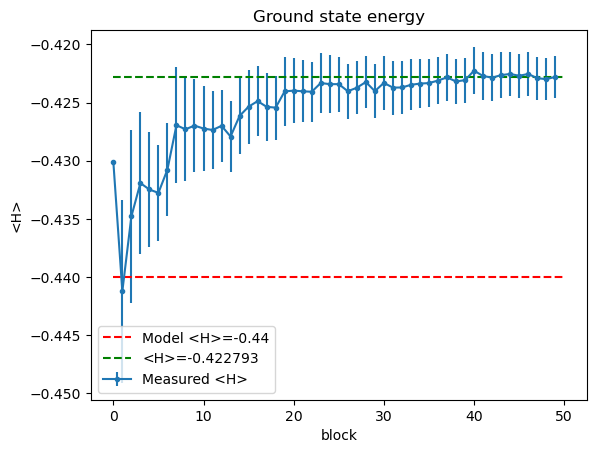

In [6]:
import matplotlib.pyplot as plt 
import pandas as pd 

df=pd.read_csv('./OUTPUT/ave.csv',sep ='\t')
GS = -0.44
plt.errorbar(df['block'],df['prog_ave'],yerr=df['err'],marker ='.',label='Measured <H>')
plt.hlines(GS,0,50,color='red',linestyle ='dashed',label=f'Model <H>={GS}')
plt.hlines(df['prog_ave'][49],0,50,color ='green',linestyle='dashed',label=f'<H>={df['prog_ave'][49]}')
plt.title('Ground state energy')
plt.xlabel('block')
plt.ylabel('<H>')
plt.legend()

print(f'Measured Ground state energy: {df['prog_ave'][49]}')